# Analysing Attacking Performance in the 2025-26 Premier League Using Goals, Shots and Shots on Target

## 1. Introduction

The following report analyses the 2025-26 Premier League season’s team data on goals, shots and shots on target to understand patterns in attacking and finishing performance across all 20 clubs. The raw dataset was cleaned to retain only the statistics relevant to this analysis, which then served as the basis for five computed metrics used throughout the report:


1.	Goals/Match= Goals Scored/Matches played
2.	Shots/Match= Shots Taken/Matches played
3.	Shots on Target/Match= Shots on Target/Matches played
4.	Conversion Rate= Goals Scored /Shots Taken
5.	Shot Accuracy= Shots on Target/Shots Taken

These five metrics were chosen and analysed together since they showcase different aspects of each team’s attacking performance. Shots and Shots on Target showcase the attacking volume; Conversion Rate and Shot Accuracy reflect efficiency; and Goals Scored reflect output. In a hypothetical situation where two teams take the same number of shots, conversion rate is a more apt measure of the efficiency of attacks since a higher conversion rate usually correlates with a higher number of goals, whereas a higher shot accuracy may not always result in a higher number of goals. That said, shot accuracy remains a useful statistic in its own right, since it captures the quality of shots being taken regardless of whether they're ultimately converted. Looking at them together, rather than any one in isolation, makes it possible to distinguish teams that create a high volume of chances from teams that convert a smaller number of chances at a higher rate.


It also includes the analysis of each team’s home and away performance across these metrics to assess whether the venue influenced attacking output and finishing efficiency.


It is important to note that the dataset also included statistics that displayed the defensive performances of each team(shots, shots on target and goals conceded) but they have been filtered out from the analysis since the analysis is “attacking focused”. As a result, this analysis does not attempt to explain overall league standings or points totals, which are shaped by defensive performance as much as attacking output — a distinction revisited later in this report's limitations section.

Source: Football-Data.co.uk
(https://www.football-data.co.uk/mmz4281/2526/E0.csv)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://www.football-data.co.uk/mmz4281/2526/E0.csv"

matches = pd.read_csv(url)

matches.iloc[:5,:10]

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0


In [2]:
home = matches[["HomeTeam", "FTHG", "HS", "HST"]].copy()

home.columns = [
    "Team",
    "Goals For",
    "Shots For",
    "Shots on Target For"
]

home["Venue"] = "Home"

away = matches[["AwayTeam", "FTAG", "AS", "AST"]].copy()

away.columns = [
    "Team",
    "Goals For",
    "Shots For",
    "Shots on Target For"
]

away["Venue"] = "Away"

team_matches = pd.concat([home, away], ignore_index=True)

team_matches.head()



,Team,Goals For,Shots For,Shots on Target For,Venue
0,Liverpool,4,19,10,Home
1,Aston Villa,0,3,3,Home
2,Brighton,1,10,4,Home
3,Sunderland,3,10,5,Home
4,Tottenham,3,16,6,Home


In [3]:
team_stats = team_matches.groupby("Team").agg(
    Matches=("Team", "count"),
    Goals_For=("Goals For", "sum"),
    Shots_For=("Shots For", "sum"),
    Shots_on_Target_For=("Shots on Target For", "sum")
).reset_index()

team_stats.head()

,Team,Matches,Goals_For,Shots_For,Shots_on_Target_For
0,Arsenal,38,71,552,186
1,Aston Villa,38,56,483,170
2,Bournemouth,38,58,525,178
3,Brentford,38,55,405,147
4,Brighton,38,52,495,176


In [4]:
team_stats["Goals per Match"] = team_stats["Goals_For"] / team_stats["Matches"]
team_stats["Shots per Match"] = team_stats["Shots_For"] / team_stats["Matches"]
team_stats["Shots on Target per Match"] = team_stats["Shots_on_Target_For"] / team_stats["Matches"]

team_stats["Conversion Rate"] = team_stats["Goals_For"] / team_stats["Shots_For"]
team_stats["Shot Accuracy"] = team_stats["Shots_on_Target_For"] / team_stats["Shots_For"]

team_stats.head()

,Team,Matches,Goals_For,Shots_For,Shots_on_Target_For,Goals per Match,Shots per Match,Shots on Target per Match,Conversion Rate,Shot Accuracy
0,Arsenal,38,71,552,186,1.868421,14.526316,4.894737,0.128623,0.336957
1,Aston Villa,38,56,483,170,1.473684,12.710526,4.473684,0.115942,0.351967
2,Bournemouth,38,58,525,178,1.526316,13.815789,4.684211,0.110476,0.339048
3,Brentford,38,55,405,147,1.447368,10.657895,3.868421,0.135802,0.362963
4,Brighton,38,52,495,176,1.368421,13.026316,4.631579,0.105051,0.355556


## 2. Part One: Overall Attacking Performance

### 2.1 Volume:
Volume of attacks has been characterised by the number of shots/match and shots on target/match. The teams that lead in the shots/match measure are the traditional top sides - **Manchester City (2nd)**, **Liverpool (3rd)** and **Arsenal (4th)**, though somewhat surprisingly **Manchester United** top this chart, despite their poor league form in the recent seasons. These teams also lead the shots on target/match metric, with the exception of Liverpool, who fall to 7th on this measure despite their high shot volume - an early sign of their shot-accuracy issues explored further later in this report. The teams that find themselves on the other end of the spectrum are **Sunderland**, **Wolves** and **Burnley**, who finished 18th,19th and 20th respectively on both metrics.


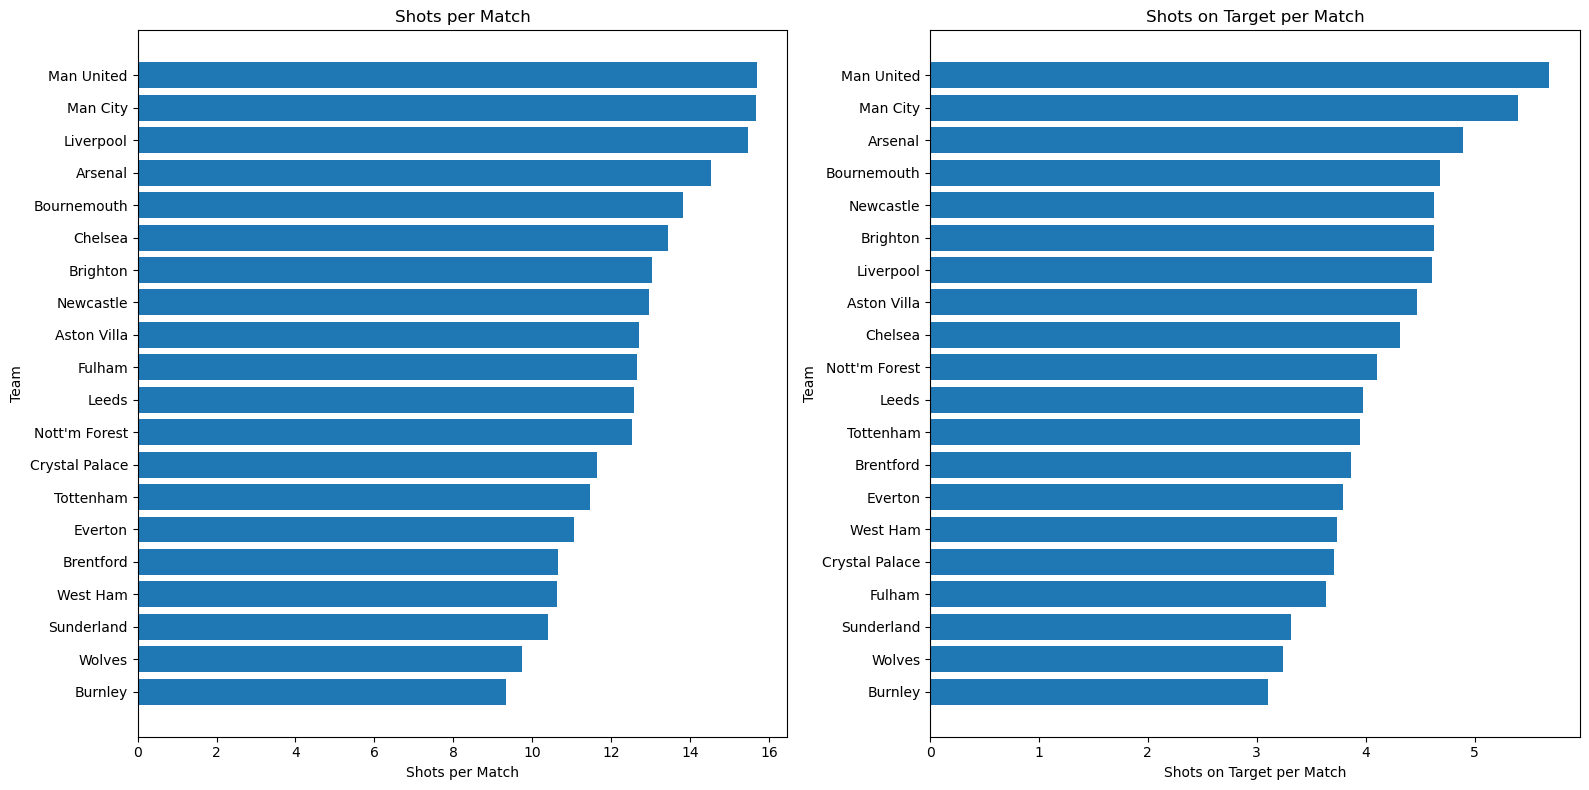

In [5]:
shots_sorted = team_stats.sort_values("Shots per Match", ascending=True)
shots_on_target_sorted = team_stats.sort_values("Shots on Target per Match", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(shots_sorted["Team"], shots_sorted["Shots per Match"])
axes[0].set_title("Shots per Match")
axes[0].set_xlabel("Shots per Match")
axes[0].set_ylabel("Team")

axes[1].barh(shots_on_target_sorted["Team"], shots_on_target_sorted["Shots on Target per Match"])
axes[1].set_title("Shots on Target per Match")
axes[1].set_xlabel("Shots on Target per Match")
axes[1].set_ylabel("Team")

plt.tight_layout()
plt.show()

### 2.2 Efficiency:
Efficiency is characterised by the **ratio of shots that result in goals (conversion rate)** and the **ratio of shots that are taken on target (shot accuracy)**. In a hypothetical situation where two teams take the same number of shots, conversion rate is a more apt measure of the efficiency of attacks since a higher conversion rate usually correlates to a higher number of goals, whereas a higher shot accuracy may not always result in a higher number of goals. Having said this, shot accuracy is also a useful statistic since it showcases the quality of shots being taken. **Brentford** lead both measures, with **Manchester City (2nd)** and **Arsenal (3rd)** behind them on the *conversion rate chart* and **Manchester United (2nd)** and **Newcastle (3rd)** behind them on the *shot accuracy chart*. **Fulham (18th)**, **Crystal Palace (19th)** and **Wolves (20th)** on the other hand recorded the worst *conversion rates*. **Leeds (18th)**, **Liverpool (19th)** and **Fulham (20th)** were on the bottom of the *shot accuracy chart*.


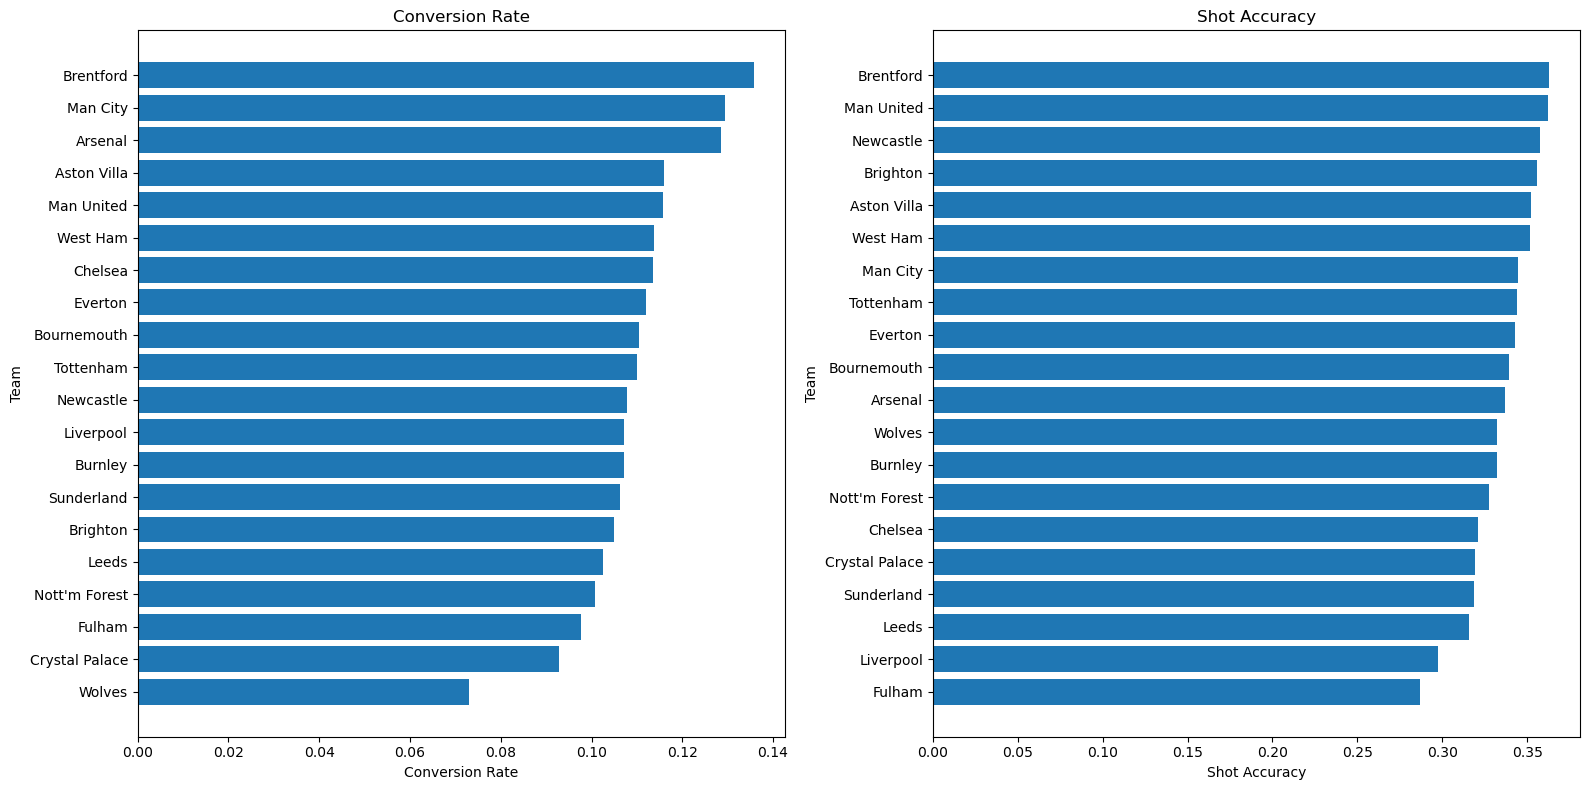

In [6]:
conversion_rate_sorted = team_stats.sort_values("Conversion Rate", ascending=True)
shot_accuracy_sorted = team_stats.sort_values("Shot Accuracy", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(conversion_rate_sorted["Team"], conversion_rate_sorted["Conversion Rate"])
axes[0].set_title("Conversion Rate")
axes[0].set_xlabel("Conversion Rate")
axes[0].set_ylabel("Team")

axes[1].barh(shot_accuracy_sorted["Team"], shot_accuracy_sorted["Shot Accuracy"])
axes[1].set_title("Shot Accuracy")
axes[1].set_xlabel("Shot Accuracy")
axes[1].set_ylabel("Team")

plt.tight_layout()
plt.show()

### 2.3 Volume vs Efficiency:
Across the league shot volume and shot efficiency do not show any consistent relationship.  A team may generate a high attacking volume (high number of shots per match) but their conversion rate may be weak, whereas another team might have a low volume but might record a higher conversion rate and a few manage both. This pattern is demonstrated in the quadrant scatter plot.


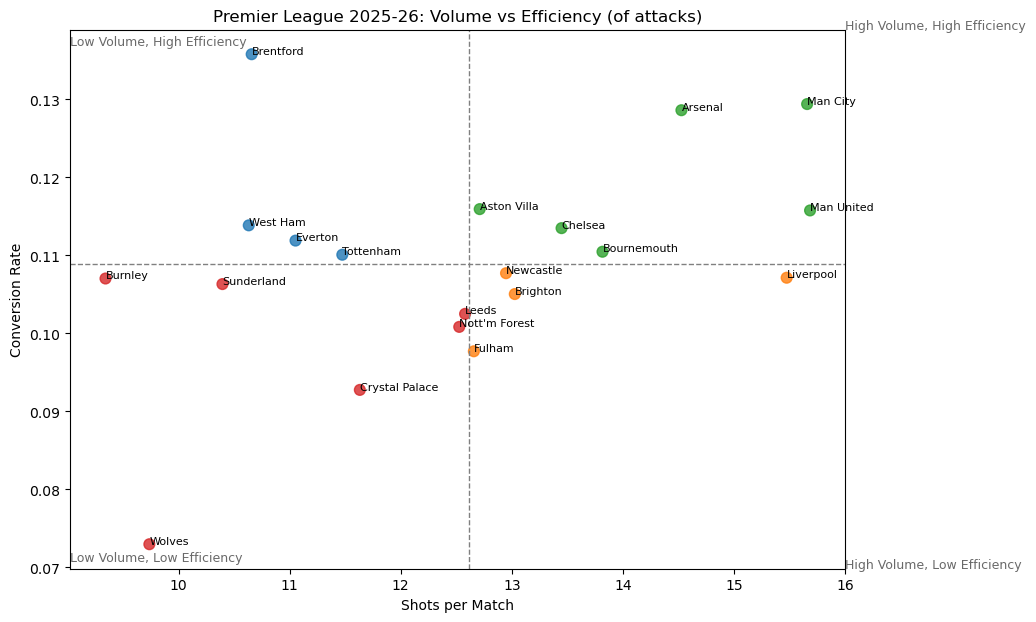

In [28]:
plt.figure(figsize=(10, 7))

x = team_stats["Shots per Match"]
y = team_stats["Conversion Rate"]

x_median = x.median()
y_median = y.median()

colors = []
for shots, conversion in zip(x, y):
    if shots >= x_median and conversion >= y_median:
        colors.append("tab:green")
    elif shots < x_median and conversion >= y_median:
        colors.append("tab:blue")
    elif shots >= x_median and conversion < y_median:
        colors.append("tab:orange")
    else:
        colors.append("tab:red")

plt.scatter(x, y, s=60, alpha=0.8, c=colors)

for i, row in team_stats.iterrows():
    plt.text(row["Shots per Match"], row["Conversion Rate"], row["Team"], fontsize=8)

plt.axvline(x_median, color="gray", linestyle="--", linewidth=1)
plt.axhline(y_median, color="gray", linestyle="--", linewidth=1)

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

plt.text(xmax, ymax, "High Volume, High Efficiency", fontsize=9, color="dimgray")
plt.text(xmin, ymax- 0.002, "Low Volume, High Efficiency", fontsize=9, color="dimgray")
plt.text(xmax, ymin, "High Volume, Low Efficiency", fontsize=9, color="dimgray")
plt.text(xmin, ymin+ 0.001, "Low Volume, Low Efficiency", fontsize=9, color="dimgray")

plt.xlabel("Shots per Match")
plt.ylabel("Conversion Rate")
plt.title("Premier League 2025-26: Volume vs Efficiency (of attacks)")
plt.savefig("quadrant_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

**Brentford** exemplify the *"low volume, high efficiency"* quadrant: despite ranking 5th bottom in shots per match, they lead the league in both shot accuracy and conversion rate — showing that a smaller number of attempts can outperform a much higher volume if shot quality is high enough. 

**Liverpool** sit almost opposite them in the *“high volume, low efficiency”* quadrant: finishing 3rd in shots per match, yet 19th in shot accuracy and 12th in conversion rate, relying on sheer volume of attempts rather than shot quality to generate output.

**Manchester City** and **Arsenal** rank highly on both metrics and found themselves in the *“high volume, high efficiency”* quadrant: ranking 2nd and 3rd respectively in conversion rates, and 2nd and 4th in shots per match.

 **Wolves** sit in the *“low volume, low efficiency”* quadrant: having recorded the second fewest shots per match in the league and the lowest conversion rate. **Burnley** recorded the fewest shots per match in the league, even fewer than Wolves- but, unlike Wolves, had a respectable conversion rate ranking 13th in the league and placing them close to the division's median efficiency despite their minimal shot volume. This contrast between Burnley and Wolves reinforces the core point that low shot volume alone doesn't guarantee poor efficiency.

### 2.4 Output:


**Manchester City** and **Arsenal** top the goals per match leaderboard (1st and 2nd respectively), despite ranking only 2nd and 4th in shots per match, and 2nd and 3rd in shots on target per match. This shows that their attacking output isn't simply a function of taking the most shots. Both sides convert their chances at a notably higher rate than most of the league, ranking 2nd and 3rd in conversion rate. **Manchester United**, by contrast, **lead both** the shots per match and shots on target per match tables, yet finish **3rd** in goals per match — behind **City** and **Arsenal**, whose superior conversion rates (2nd and 3rd, versus Manchester United's 5th) close the gap despite United generating more shooting opportunities. **Crystal Palace (18th)** found themselves on the bottom of this metric along with the two teams that recorded the worst attacking performances- **Burnley (19th)** and **Wolves (20th)**.


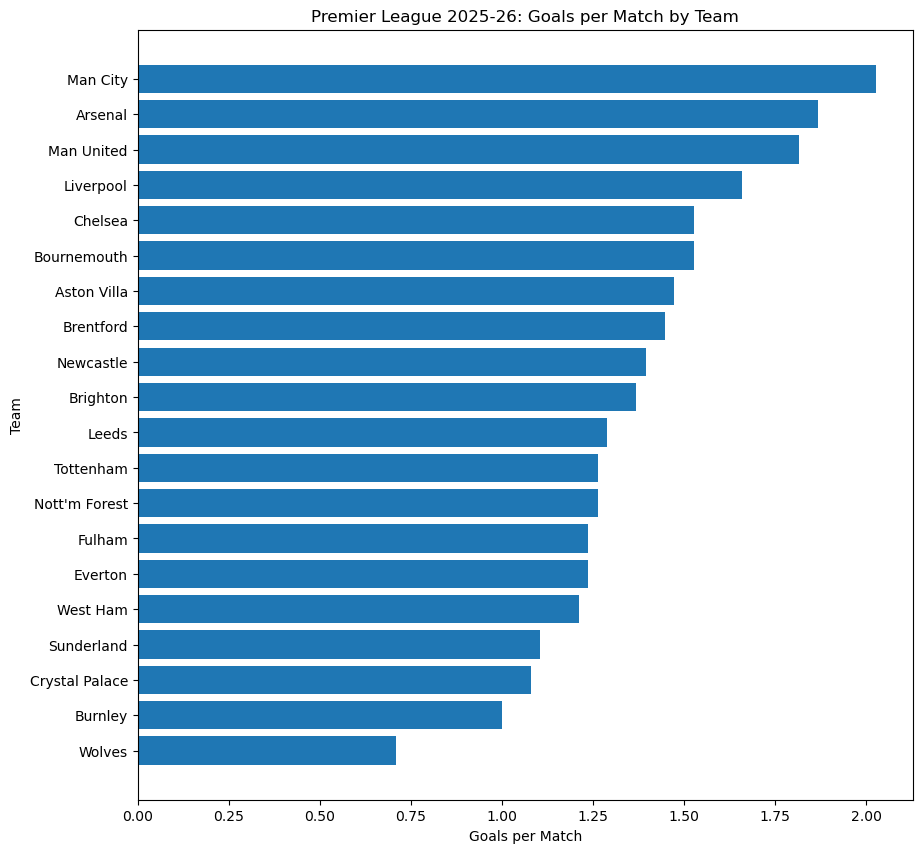

In [8]:
attacking_output=team_stats.sort_values("Goals per Match",ascending=True)
plt.figure(figsize=(10, 10))
plt.barh(attacking_output["Team"], attacking_output["Goals per Match"])
plt.xlabel("Goals per Match")
plt.ylabel("Team")
plt.title("Premier League 2025-26: Goals per Match by Team")
plt.show()

### 2.5 Notable Team Profiles:

#### Brentford
Brentford recorded the highest shot accuracy and conversion rate in the league despite being one of the smaller teams and taking the 5th least shots per match. This came down to the quality they possessed in attack with players like Dango Ouattara, Kevin Schade, Keane Lewis-Potter and their main man up front Igor Thiago, who finished 2nd on the top scorers list with 22 goals. Keith Andrews, former set piece coach at the club, succeeded Thomas Frank as manager, and his flexible style, utilising his full backs to get higher up the pitch, resulted in Brentford having a very successful season — agonisingly missing out on Europe to Brighton on goal difference.


#### Manchester United
Manchester United took the most shots and shots on target, had the second best shot accuracy, the 5th highest conversion rate and scored the 3rd most goals. This came down to the recruitment of proven players like Bryan Mbeumo and Matheus Cunha, the signing of Benjamin Sesko, and above all their maestro Bruno Fernandes, who broke the Premier League assist record with 21 assists. Reduced commitments elsewhere also helped — an early FA Cup exit and a shock loss to Grimsby Town in the EFL Cup, plus no European football, let them focus solely on the league.


#### Manchester City & Arsenal
City and Arsenal's goal-scoring success comes down to individual attacking quality rather than shot volume. Haaland, Cherki, and Bernardo Silva led City's line, with full-back Nico O'Reilly's breakout season adding an unexpected extra outlet. Arsenal's case is arguably the more impressive of the two: despite significant injuries to Saka, Merino, Eberechi Eze, and Ødegaard, their depth in attack — Martinelli, Madueke, Havertz, and Trossard among others — let them sustain elite output regardless of who was available.


#### Liverpool
Liverpool recorded the 2nd worst shot accuracy in the league (0.298), ahead of only Fulham, despite being 3rd in shots/match and 4th in total goals — their poor shot quality masked by sheer volume of attacks. Alexander Isak sustained a serious injury, missing 28 games during the season. Hugo Ekitiké started brightly but went through a lengthy scoring drought before also picking up a late injury, and Florian Wirtz, their record signing, also failed to hit the ground running. Despite this, their overall output stayed impressive, thanks to their willingness to win the ball back high up the pitch.


#### Burnley
Burnley took the least shots and shots on target, had the 13th highest conversion rate and scored the 2nd least goals in the league — a reasonable return for a club with little proven Premier League pedigree, given talented players like Zeki Amdouni, Jaden Anthony and striker Zian Flemming's impressive first campaign.


#### Wolves
Wolves had the 2nd fewest shots and shots on target per match, the worst conversion rate in the league, and scored the fewest goals overall. Vitor Pereira was sacked after just two points from their opening ten games; his replacement Rob Edwards fared little better, winning just five of his 30 games before being sacked himself following relegation. This came down to poor recruitment — after losing Matheus Cunha, Rayan Aït-Nouri, and Nelson Semedo, the club spent roughly £100m on largely unproven talent, including Tolu Arokodare, Fer Lopez, and Jhon Arias, none of whom arrested the decline.


#### Burnley vs. Wolves
Burnley ranked dead last in shots per match, yet still posted a respectable conversion rate for that limited output, finishing 13th in the league. Wolves, despite taking slightly more shots per match than Burnley, finished with the worst conversion rate in the league. Even among two relegated sides, that gap stands out as one of the clearest single explanations for why Wolves' campaign was arguably the more disastrous of the two.


## 3. Part Two: Home vs Away Splits

### 3.1 Methodology:
To assess whether the attacking metrics: shots per match, shots on target per match, shot accuracy, conversion rate and goals per match are influenced by venue, each metric has been calculated separately for every team’s home and away fixtures.

**Difference= Home Value- Away Value**

A positive difference implies better performance at home than away on the particular metric (for example, Newcastle's Goals per Match Difference of +1.00 means they scored, on average, one more goal per match at home than away). A negative difference implies the opposite- better performance away from home than at home on the particular metric (for example, Nottingham Forest recorded a Goals per Match Difference of -0.42, which means that they scored more goals per match away from home than at home). The size of the difference (whether positive or negative) indicates the gap between the home and away performances of each team based on a metric. This calculation was applied to each of the 20 teams belonging to the dataset and it forms the basis for the home and away comparisons of each team’s attacking performance, discussed in this section.


In [9]:
venue_stats = team_matches.groupby(["Team","Venue"]).agg(
    Matches=("Team", "count"),
    Goals_For=("Goals For", "sum"),
    Shots_For=("Shots For", "sum"),
    Shots_on_Target_For=("Shots on Target For", "sum")
).reset_index()

venue_stats.head()

,Team,Venue,Matches,Goals_For,Shots_For,Shots_on_Target_For
0,Arsenal,Away,19,30,247,91
1,Arsenal,Home,19,41,305,95
2,Aston Villa,Away,19,24,222,78
3,Aston Villa,Home,19,32,261,92
4,Bournemouth,Away,19,29,250,92


In [10]:
venue_stats["Goals per Match"] = venue_stats["Goals_For"] / venue_stats["Matches"]
venue_stats["Shots per Match"] = venue_stats["Shots_For"] / venue_stats["Matches"]
venue_stats["Shots on Target per Match"] = venue_stats["Shots_on_Target_For"] / venue_stats["Matches"]
venue_stats["Conversion Rate"] = venue_stats["Goals_For"] / venue_stats["Shots_For"]
venue_stats["Shot Accuracy"] = venue_stats["Shots_on_Target_For"] / venue_stats["Shots_For"]

venue_stats.head()

,Team,Venue,Matches,Goals_For,Shots_For,Shots_on_Target_For,Goals per Match,Shots per Match,Shots on Target per Match,Conversion Rate,Shot Accuracy
0,Arsenal,Away,19,30,247,91,1.578947,13.000000,4.789474,0.121457,0.368421
1,Arsenal,Home,19,41,305,95,2.157895,16.052632,5.000000,0.134426,0.311475
2,Aston Villa,Away,19,24,222,78,1.263158,11.684211,4.105263,0.108108,0.351351
3,Aston Villa,Home,19,32,261,92,1.684211,13.736842,4.842105,0.122605,0.352490
4,Bournemouth,Away,19,29,250,92,1.526316,13.157895,4.842105,0.116000,0.368000


In [11]:
home_stats=venue_stats[venue_stats["Venue"]=="Home"]
away_stats=venue_stats[venue_stats["Venue"]=="Away"]

home_stats.head()

,Team,Venue,Matches,Goals_For,Shots_For,Shots_on_Target_For,Goals per Match,Shots per Match,Shots on Target per Match,Conversion Rate,Shot Accuracy
1,Arsenal,Home,19,41,305,95,2.157895,16.052632,5.000000,0.134426,0.311475
3,Aston Villa,Home,19,32,261,92,1.684211,13.736842,4.842105,0.122605,0.352490
5,Bournemouth,Home,19,29,275,86,1.526316,14.473684,4.526316,0.105455,0.312727
7,Brentford,Home,19,33,228,78,1.736842,12.000000,4.105263,0.144737,0.342105
9,Brighton,Home,19,30,262,94,1.578947,13.789474,4.947368,0.114504,0.358779


In [12]:
home_vs_away = pd.merge(
    home_stats,
    away_stats,
    on="Team",
    suffixes=("_Home", "_Away")
)

home_vs_away.head()

,Team,Venue_Home,Matches_Home,Goals_For_Home,Shots_For_Home,Shots_on_Target_For_Home,Goals per Match_Home,Shots per Match_Home,Shots on Target per Match_Home,Conversion Rate_Home,...,Venue_Away,Matches_Away,Goals_For_Away,Shots_For_Away,Shots_on_Target_For_Away,Goals per Match_Away,Shots per Match_Away,Shots on Target per Match_Away,Conversion Rate_Away,Shot Accuracy_Away
0,Arsenal,Home,19,41,305,95,2.157895,16.052632,5.000000,0.134426,...,Away,19,30,247,91,1.578947,13.000000,4.789474,0.121457,0.368421
1,Aston Villa,Home,19,32,261,92,1.684211,13.736842,4.842105,0.122605,...,Away,19,24,222,78,1.263158,11.684211,4.105263,0.108108,0.351351
2,Bournemouth,Home,19,29,275,86,1.526316,14.473684,4.526316,0.105455,...,Away,19,29,250,92,1.526316,13.157895,4.842105,0.116000,0.368000
3,Brentford,Home,19,33,228,78,1.736842,12.000000,4.105263,0.144737,...,Away,19,22,177,69,1.157895,9.315789,3.631579,0.124294,0.389831
4,Brighton,Home,19,30,262,94,1.578947,13.789474,4.947368,0.114504,...,Away,19,22,233,82,1.157895,12.263158,4.315789,0.094421,0.351931


#### The five difference metrics are computed below:

In [13]:
home_vs_away["Goals per Match Difference"] = (
    home_vs_away["Goals per Match_Home"] - home_vs_away["Goals per Match_Away"]
)

home_vs_away["Shots per Match Difference"] = (
    home_vs_away["Shots per Match_Home"] - home_vs_away["Shots per Match_Away"]
)
home_vs_away["Shots on Target per Match Difference"] = (
    home_vs_away["Shots on Target per Match_Home"] - home_vs_away["Shots on Target per Match_Away"]
)

home_vs_away["Conversion Rate Difference"] = (
    home_vs_away["Conversion Rate_Home"] - home_vs_away["Conversion Rate_Away"]
)
home_vs_away["Shot Accuracy Difference"] = (
    home_vs_away["Shot Accuracy_Home"] - home_vs_away["Shot Accuracy_Away"]
)
home_vs_away.head()

,Team,Venue_Home,Matches_Home,Goals_For_Home,Shots_For_Home,Shots_on_Target_For_Home,Goals per Match_Home,Shots per Match_Home,Shots on Target per Match_Home,Conversion Rate_Home,...,Goals per Match_Away,Shots per Match_Away,Shots on Target per Match_Away,Conversion Rate_Away,Shot Accuracy_Away,Goals per Match Difference,Shots per Match Difference,Shots on Target per Match Difference,Conversion Rate Difference,Shot Accuracy Difference
0,Arsenal,Home,19,41,305,95,2.157895,16.052632,5.000000,0.134426,...,1.578947,13.000000,4.789474,0.121457,0.368421,0.578947,3.052632,0.210526,0.012969,-0.056946
1,Aston Villa,Home,19,32,261,92,1.684211,13.736842,4.842105,0.122605,...,1.263158,11.684211,4.105263,0.108108,0.351351,0.421053,2.052632,0.736842,0.014497,0.001139
2,Bournemouth,Home,19,29,275,86,1.526316,14.473684,4.526316,0.105455,...,1.526316,13.157895,4.842105,0.116000,0.368000,0.000000,1.315789,-0.315789,-0.010545,-0.055273
3,Brentford,Home,19,33,228,78,1.736842,12.000000,4.105263,0.144737,...,1.157895,9.315789,3.631579,0.124294,0.389831,0.578947,2.684211,0.473684,0.020443,-0.047725
4,Brighton,Home,19,30,262,94,1.578947,13.789474,4.947368,0.114504,...,1.157895,12.263158,4.315789,0.094421,0.351931,0.421053,1.526316,0.631579,0.020083,0.006847


In [14]:
home_vs_away[
    [
        "Team",
        "Goals per Match Difference",
        "Shots per Match Difference",
        "Shots on Target per Match Difference",
        "Conversion Rate Difference",
        "Shot Accuracy Difference"
    ]
].reset_index(drop=True)

,Team,Goals per Match Difference,Shots per Match Difference,Shots on Target per Match Difference,Conversion Rate Difference,Shot Accuracy Difference
0,Arsenal,0.578947,3.052632,0.210526,0.012969,-0.056946
1,Aston Villa,0.421053,2.052632,0.736842,0.014497,0.001139
2,Bournemouth,0.000000,1.315789,-0.315789,-0.010545,-0.055273
3,Brentford,0.578947,2.684211,0.473684,0.020443,-0.047725
4,Brighton,0.421053,1.526316,0.631579,0.020083,0.006847
5,Burnley,-0.105263,3.000000,0.421053,-0.046850,-0.063302
6,Chelsea,-0.315789,3.421053,-0.210526,-0.053220,-0.098904
7,Crystal Palace,-0.157895,3.368421,0.368421,-0.041303,-0.062007
8,Everton,0.263158,2.315789,1.052632,0.000367,0.023661
9,Fulham,0.684211,3.000000,0.736842,0.031335,-0.009925


### 3.2 Home vs Away Performance Clusters:

Applying the Home - Away difference across all five metrics reveals two clear clusters of teams: those whose attacking performance is meaningfully stronger at home, and those who perform significantly better away from home.

The chart below shows the Goals per Match Difference for all 20 teams, which offers the clearest single visual summary of each team's home/away split- though the discussion that follows also draws on shot accuracy and conversion rate differences to explain why certain teams lean one way or the other.

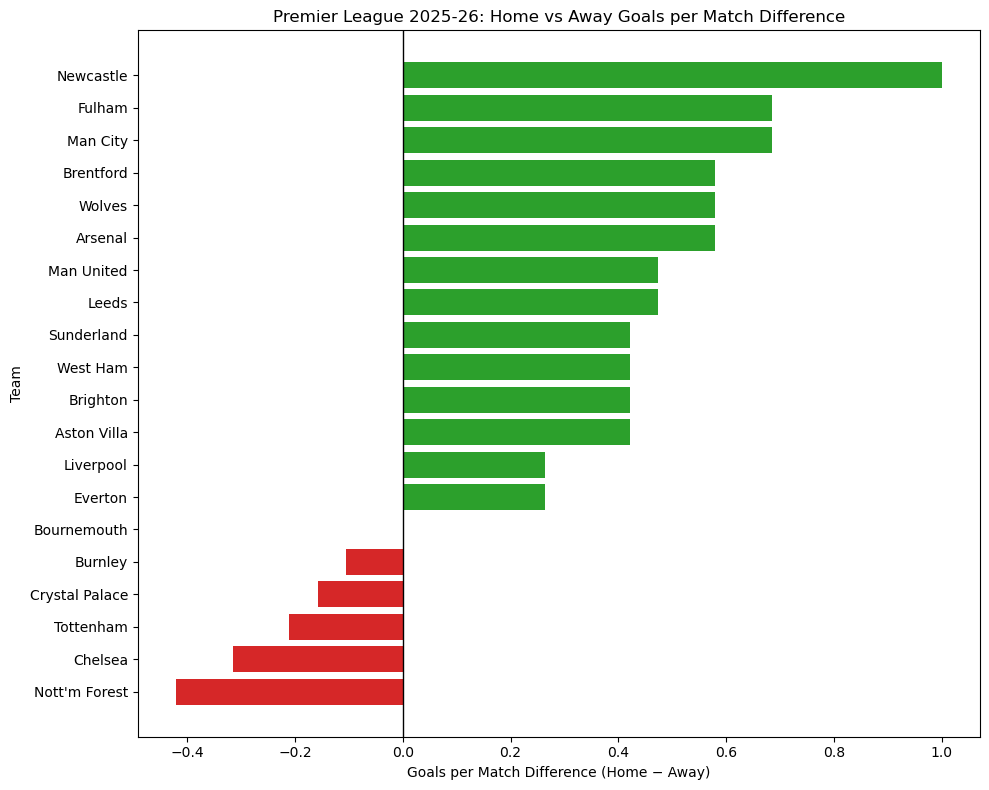

In [29]:
comparison = home_vs_away.sort_values("Goals per Match Difference", ascending=True)

colors = ["tab:red" if val < 0 else "tab:green" for val in comparison["Goals per Match Difference"]]

plt.figure(figsize=(10, 8))
plt.barh(comparison["Team"], comparison["Goals per Match Difference"], color=colors)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Goals per Match Difference (Home − Away)")
plt.ylabel("Team")
plt.title("Premier League 2025-26: Home vs Away Goals per Match Difference")

plt.tight_layout()
plt.savefig("goals_diff_chart.png", dpi=150, bbox_inches="tight")
plt.show()

#### "Home Fortress" teams

**Newcastle** and **Fulham** stand out as the league's two clearest "home fortress" teams, sides whose attacking output is meaningfully stronger at home than away. Newcastle ranked first in the goals per match difference metric (+1.00), first in shot accuracy difference, 2nd in shots on target per match difference, and first in conversion rate difference, sweeping every metric and showcasing how much better they were at home. Fulham also had significantly better attacking performances at home, ranking 2nd in goals/match difference (+0.68) and 3rd in conversion rate difference. Both teams are discussed in greater depth later in this section.

#### "Away Boosted" Teams

On the other end of the spectrum, teams like **Nottingham Forest**, **Chelsea**, **Tottenham** and **Palace** have had significantly better attacking performances at away venues. This can be seen in the goals per match difference chart, where a negative value depicts a higher number of goals being scored at away venues. The four teams sitting at the bottom of this metric are Forest (−0.42), Chelsea (−0.31), Tottenham (−0.21) and Palace (−0.15).

#### The Neutral Case of Bournemouth

In contrast to both of the above, **Bournemouth** stand out as the clearest exception, having scored the exact same number of goals in both their home and away fixtures. This is reflected in the other metrics too: Bournemouth recorded a very low shot accuracy difference (−0.05) and conversion rate difference (−0.01). Despite the departure of important players like Antoine Semenyo, Illia Zabarnyi, Milos Kerkez and Dean Huijsen before the season, they finished 6th and qualified for the Europa League, exceeding all expectations - a result owed largely to manager Andoni Iraola's high intensity, high pressing style, instilling the mindset of winning the ball back high up the pitch.

### 3.3 The Volume/Efficiency Paradox

#### Nottingham Forest
Forest show the most negative shot accuracy difference of any team (−0.152) and the most negative conversion rate difference too. The rift between owner Evangelos Marinakis and manager Nuno Espirito Santos didn't set a good precedent, and Nuno's sacking brought in Ange Postecoglou, who went winless (0-1-5) in his short tenure. Forest only found their feet after Sean Dyche's appointment, who helped them accumulate 22 points in 18 games before being sacked himself — Vitor Pereira, their current manager, came in towards the end of the season and did a decent job.


#### Chelsea
Chelsea show the same pattern, just less pronounced, with the second-most negative shot accuracy and conversion rate differences. They finished a poor 10th, despite Todd Boehly spending over £1.5 billion on transfers since 2022 — their best season under his ownership still only 4th (2024-25). Managerial instability and six losses in a row between March and May capped another season that failed to qualify for Europe.


#### The Paradox
What makes Forest and Chelsea particularly counterintuitive is that their higher efficiency away from home runs directly opposite to their shot volume — Forest take almost five more shots per match at home (the largest gap in the league), Chelsea the 5th-highest.

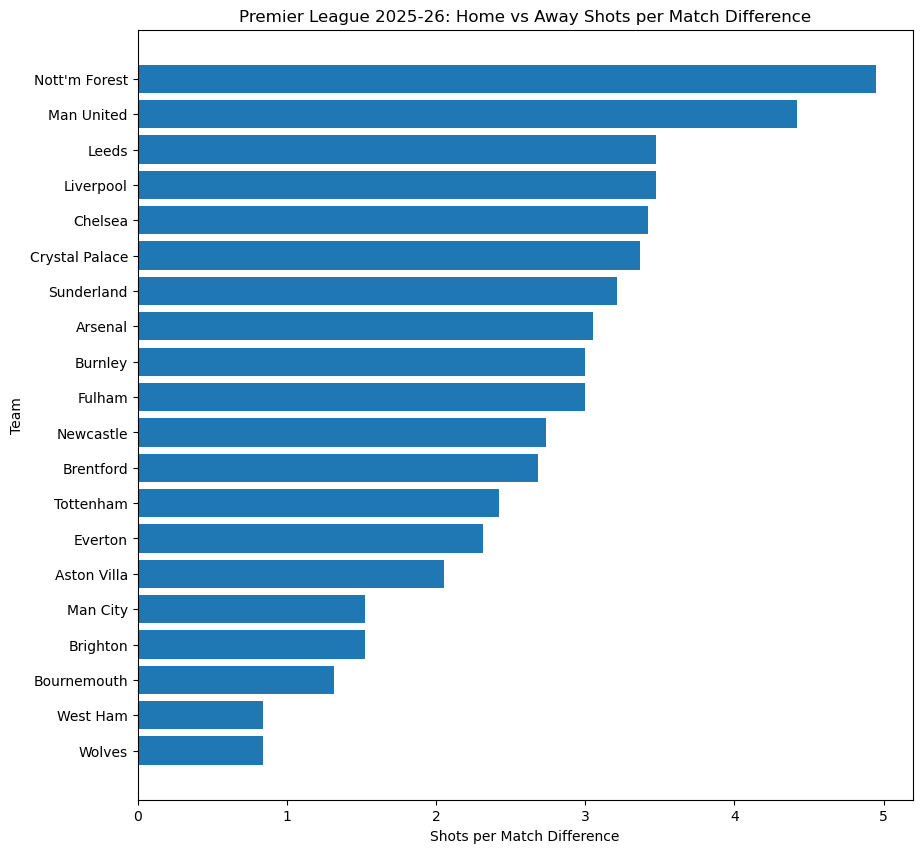

In [16]:
shots_per_match_diff=home_vs_away.sort_values("Shots per Match Difference",ascending=True)
plt.figure(figsize=(10, 10))
plt.barh(shots_per_match_diff["Team"], shots_per_match_diff ["Shots per Match Difference"])
plt.xlabel("Shots per Match Difference")
plt.ylabel("Team")
plt.title("Premier League 2025-26: Home vs Away Shots per Match Difference")
plt.show()

Forest's counter-attacking style away from home forced opponents higher up the pitch, giving attackers like Dan Ndoye, Hudson Odoi and Igor Jesus more space to create higher-quality chances. Chelsea's stronger away form may be tied to the tense atmosphere at Stamford Bridge, where a lack of confidence in the ownership left players facing less pressure on the road. The chart below makes this pattern easy to compare across all four teams at once - Forest and Chelsea's steeper lines reflect a more pronounced home-to-away swing than Palace or Tottenham show on the same three metrics.

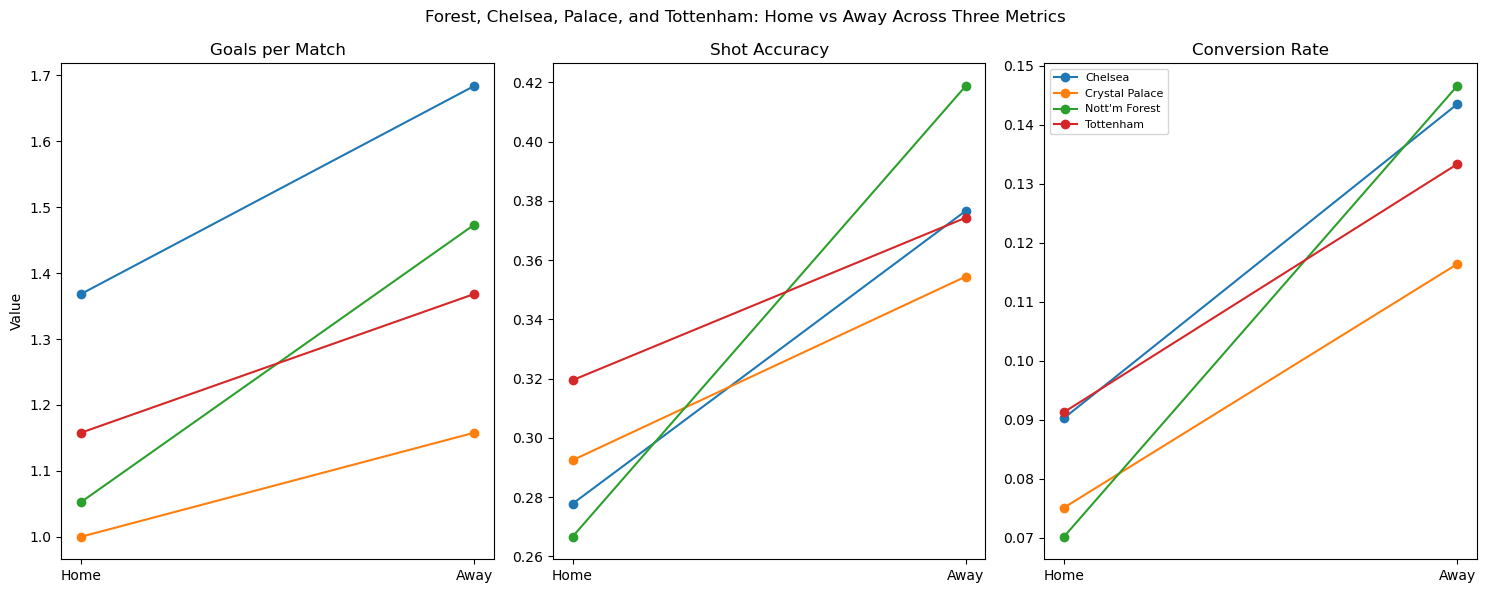

In [17]:
paradox_teams = ["Nott'm Forest", "Chelsea", "Crystal Palace", "Tottenham"]

metrics = ["Goals per Match", "Shot Accuracy", "Conversion Rate"]

subset = home_vs_away[home_vs_away["Team"].isin(paradox_teams)]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, metric in zip(axes, metrics):
    for i, row in subset.iterrows():
        home_val = row[f"{metric}_Home"]
        away_val = row[f"{metric}_Away"]
        ax.plot([0, 1], [home_val, away_val], marker="o", label=row["Team"])
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Home", "Away"])
    ax.set_title(metric)

axes[0].set_ylabel("Value")
axes[-1].legend(loc="best", fontsize=8)

plt.suptitle("Forest, Chelsea, Palace, and Tottenham: Home vs Away Across Three Metrics")
plt.tight_layout()
plt.show()

#### Crystal Palace
Palace sit 16th on both conversion rate difference (−0.041) and shot accuracy difference (−0.06), posting the second-worst overall conversion rate in the league — suggesting their away improvement is less about form on the road and more about how poor they are at home. This likely comes down to competing across several competitions with a squad nowhere near the depth of the bigger clubs — they won the Community Shield, reached the FA Cup third round and EFL Cup quarter-finals (losing to eventual finalists Arsenal on penalties), and won the UEFA Conference League, their first ever European trophy. Oliver Glasner, who's brought three major accolades to Selhurst Park, deserves real credit given how thin his squad has been.


#### Tottenham
Spurs also posted a negative shot accuracy difference (−0.05) and conversion rate difference (−0.04), winning just 3 of 19 home games. This likely stems from managerial instability — three managers across the season. Thomas Frank underperformed after high pre-season expectations following a strong Super Cup showing against PSG, Igor Tudor managed just 1 point from 5 games as interim, and Roberto De Zerbi was brought in to steady the ship.


#### Palace and Tottenham: Same Volume Pattern
Palace and Tottenham, like Forest and Chelsea, also had higher attacking volume at home — 3.36 and 2.42 more shots/match respectively, ranking 6th and 13th. Spurs' higher home volume likely reflects their poor home form: falling behind in most home games pushed them into taking more shots from outside the box and harder-to-convert positions, which also explains their better away conversion rate.


### 3.4 Newcastle as the Standout Case

Newcastle had a higher number of shots on target per match, higher conversion rate, higher shot accuracy, and scored more goals per match at home than away. They ranked first in goals/match difference (+1.00), first in shot accuracy difference, 2nd in shots on target/match difference, and first in conversion rate difference — sweeping every metric and showcasing just how much better they were at home. This likely comes down to the atmosphere at St James' Park, one of the most electrifying venues in the league, where the fanbase gets fully behind the team — evident in the 2023-24 Champions League, when Newcastle beat future back-to-back champions PSG 4-1 at home despite Mbappé and Ousmane Dembélé on their roster, a result that helped cement the Geordies' reputation as one of the league's most passionate fanbases.

The chart below shows all four of Newcastle's metric differences together, visually confirming their sweep.

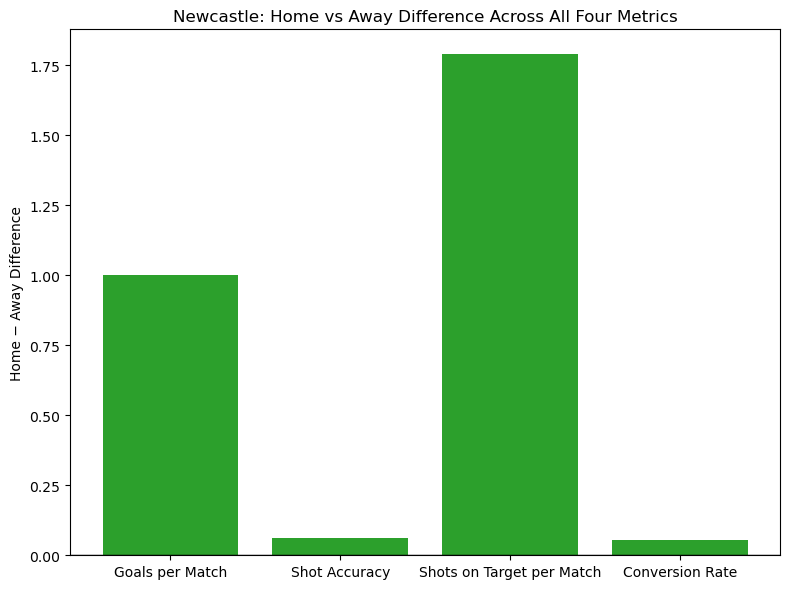

In [18]:
newcastle = home_vs_away[home_vs_away["Team"] == "Newcastle"].iloc[0]

metrics = ["Goals per Match Difference", "Shot Accuracy Difference", 
           "Shots on Target per Match Difference", "Conversion Rate Difference"]

values = [newcastle[m] for m in metrics]

labels = ["Goals per Match", "Shot Accuracy", "Shots on Target per Match", "Conversion Rate"]

plt.figure(figsize=(8, 6))
plt.bar(labels, values, color="tab:green")

plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Home − Away Difference")
plt.title("Newcastle: Home vs Away Difference Across All Four Metrics")

plt.tight_layout()
plt.show()

## 4. Limitations of the Analysis

### Sunderland
Sunderland's season is arguably the clearest reminder in this analysis that attacking output alone doesn't determine league success. They ranked **3rd-bottom** in both shots per match and shots on target per match, posted below-average shot accuracy and conversion rate, and scored the **4th-fewest** goals per game in the league — by these metrics alone, they would be assumed to be a team fighting relegation, not pushing for Europe. Yet they finished with 54 points in 7th place, securing Europa League qualification in their first season back in the top flight after a nine-year absence. This gap between what the numbers predict and what they actually achieved suggests defensive solidity and game management mattered just as much, if not more, than attacking output - much of it credited to the signing of veteran Granit Xhaka, who brought experience and stability to midfield.


### Data Scope
It is worth acknowledging the boundaries of what this analysis can actually prove. This attacking analysis includes shots, shots on target, shot accuracy, conversion rate and goals, but does not include metrics like Expected Goals (xG) or shot location - a shot from 30 yards that tests the keeper and one from 5 yards are flagged identically as a shot on target, despite nowhere near the same chance of conversion. The explanations offered throughout this report - Forest's counter-attacking style, Chelsea's ownership unrest, Spurs' managerial instability, Newcastle's home advantage - are reasonable inferences drawn from the analysis and from watching the games, but they are not conclusions the data directly proves. Confirming them further would require xG models, shot location data, and defensive statistics for each team.


## 5. Appendix

The table below summarises the rankings of all 20 teams across the five core attacking metrics examined in this analysis. It also includes each team's Goals per Match and Conversion Rate differences between home and away venues, showing how much a team's scoring output changes by venue, and how efficiently they convert their chances into goals at home compared to away. Teams are sorted according to their final league position at the end of the season.

In [27]:
appendix = team_stats[["Team", "Shots per Match", "Shots on Target per Match", 
                         "Shot Accuracy", "Conversion Rate", "Goals per Match"]].copy()

appendix["Shots/Match Rank"] = appendix["Shots per Match"].rank(ascending=False, method="min").astype(int)
appendix["Shots on Target/Match Rank"] = appendix["Shots on Target per Match"].rank(ascending=False, method="min").astype(int)
appendix["Shot Accuracy Rank"] = appendix["Shot Accuracy"].rank(ascending=False, method="min").astype(int)
appendix["Conversion Rate Rank"] = appendix["Conversion Rate"].rank(ascending=False, method="min").astype(int)
appendix["Goals/Match Rank"] = appendix["Goals per Match"].rank(ascending=False, method="min").astype(int)

venue_diffs = home_vs_away[["Team", "Goals per Match Difference", "Conversion Rate Difference"]]
appendix = pd.merge(appendix, venue_diffs, on="Team")

appendix_table = appendix[["Team", "Shots/Match Rank", "Shots on Target/Match Rank", 
                             "Shot Accuracy Rank", "Conversion Rate Rank", "Goals/Match Rank",
                             "Goals per Match Difference", "Conversion Rate Difference"]].copy()

final_positions = {
     "Arsenal": 1,"Man City": 2, "Man United": 3,"Aston Villa":4,"Liverpool":5,
    "Bournemouth":6,"Sunderland": 7,"Brighton":8,"Brentford":9,"Chelsea": 10,
    "Fulham":11,"Newcastle":12,"Everton":13,"Leeds":14,"Crystal Palace":15,
    "Nott'm Forest":16,"Tottenham":17,"West Ham":18,"Burnley":19,"Wolves":20
}

appendix_table["League Position"] = appendix_table["Team"].map(final_positions)
appendix_table = appendix_table.sort_values("League Position").reset_index(drop=True)
appendix_table.index = appendix_table.index + 1
appendix_table

,Team,Shots/Match Rank,Shots on Target/Match Rank,Shot Accuracy Rank,Conversion Rate Rank,Goals/Match Rank,Goals per Match Difference,Conversion Rate Difference,League Position
1,Arsenal,4,3,11,3,2,0.578947,0.012969,1
2,Man City,2,2,7,2,1,0.684211,0.031157,2
3,Man United,1,1,2,5,3,0.473684,-0.002482,3
4,Aston Villa,9,8,5,4,7,0.421053,0.014497,4
5,Liverpool,3,7,19,12,4,0.263158,-0.007136,5
6,Bournemouth,5,4,10,9,5,0.000000,-0.010545,6
7,Sunderland,18,18,17,14,17,0.421053,0.007853,7
8,Brighton,7,5,4,15,10,0.421053,0.020083,8
9,Brentford,16,13,1,1,8,0.578947,0.020443,9
10,Chelsea,6,9,15,7,5,-0.315789,-0.053220,10
